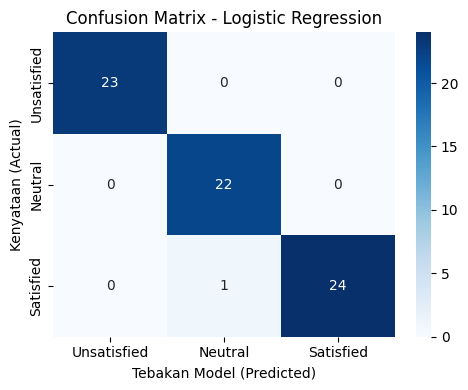

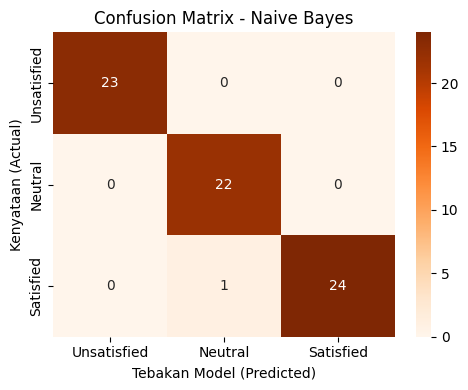


PROSES SELESAI!
1. Dua file gambar Confusion Matrix berhasil disimpan.
2. File 'model_logreg.pkl' dan 'scaler.pkl'


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

df_eval = pd.read_csv('E-commerce Customer Behavior Cleaned (1).csv')

# Pisahkan Fitur dan Target (Satisfaction Level)
X_eval = df_eval.drop(columns=['Satisfaction Level'])
y_eval = df_eval['Satisfaction Level']

# Bagi data (Train-Test Split) persis dengan settingan Vian
X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

# Standardisasi / Scaling menggunakan StandardScaler
scaler_ev = StandardScaler()
X_train_scaled = scaler_ev.fit_transform(X_train_ev)
X_test_scaled = scaler_ev.transform(X_test_ev)

# Latih ulang model Logistic Regression secara instan
logreg_ev = LogisticRegression(max_iter=1000, random_state=42)
logreg_ev.fit(X_train_scaled, y_train_ev)
y_pred_lr_ev = logreg_ev.predict(X_test_scaled)

# Latih ulang model Naive Bayes secara instan
nb_ev = GaussianNB()
nb_ev.fit(X_train_scaled, y_train_ev)
y_pred_nb_ev = nb_ev.predict(X_test_scaled)

# ==========================================
# PLOT CONFUSION MATRIX (HEATMAP)
# ==========================================
labels = ['Unsatisfied', 'Neutral', 'Satisfied']

# Plot untuk Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_ev, y_pred_lr_ev), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.tight_layout()
plt.savefig('confusion_matrix_logreg.png', dpi=300) # Otomatis tersimpan jadi gambar
plt.show()

# Plot untuk Naive Bayes
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_ev, y_pred_nb_ev), annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.tight_layout()
plt.savefig('confusion_matrix_naive_bayes.png', dpi=300) # Otomatis tersimpan jadi gambar
plt.show()

# ==========================================
# EXPORT OBJEK MODEL & SCALER (.PKL)
# ==========================================
with open('model_logreg.pkl', 'wb') as f:
    pickle.dump(logreg_ev, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_ev, f)

print("\n=======================================================")
print("PROSES SELESAI!")
print("1. Dua file gambar Confusion Matrix berhasil disimpan.")
print("2. File 'model_logreg.pkl' dan 'scaler.pkl'")
print("=======================================================")